In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/syedaeman2212/shoes-sales-dataset/shoes_sales_dataset.csv


# 1. Executive Summary:

## Business Goal:
Global footwear brands want to optimize pricing, inventory, and channel strategy.
This project builds a predictive system to forecast Units Sold per transaction, identify revenue drivers, and provide actionable commercial insights.


## ML Task:
* Supervised Regression – Predict Units_Sold


## Why Units_Sold?


* Directly tied to inventory planning
* Indirectly determines revenue
* More actionable than predicting revenue (which includes price leakage)

# 2. Problem Framing
🎯 Business Problem

Retail leaders ask:

* Which products will sell more units?
* Does price elasticity differ by brand and channel?
* Which features drive high sales volume?

In [2]:
df = pd.read_csv("/kaggle/input/datasets/syedaeman2212/shoes-sales-dataset/shoes_sales_dataset.csv")

In [3]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sale_ID        1000 non-null   object 
 1   Date           1000 non-null   object 
 2   Brand          1000 non-null   object 
 3   Shoe_Type      1000 non-null   object 
 4   Color          1000 non-null   object 
 5   Country        1000 non-null   object 
 6   Sales_Channel  1000 non-null   object 
 7   Price_USD      1000 non-null   float64
 8   Units_Sold     1000 non-null   int64  
 9   Revenue_USD    1000 non-null   float64
dtypes: float64(2), int64(1), object(7)
memory usage: 78.3+ KB


,Price_USD,Units_Sold,Revenue_USD
count,1000.000000,1000.000000,1000.00000
mean,137.856420,10.584000,1453.18603
std,64.270059,5.842181,1112.32648
min,31.020000,1.000000,32.38000
25%,81.915000,6.000000,561.05000
50%,139.295000,10.000000,1132.62500
75%,193.752500,16.000000,2163.35000
max,249.940000,20.000000,4938.40000


# 3. Data Understanding & EDA

## 3.1 Target Distribution

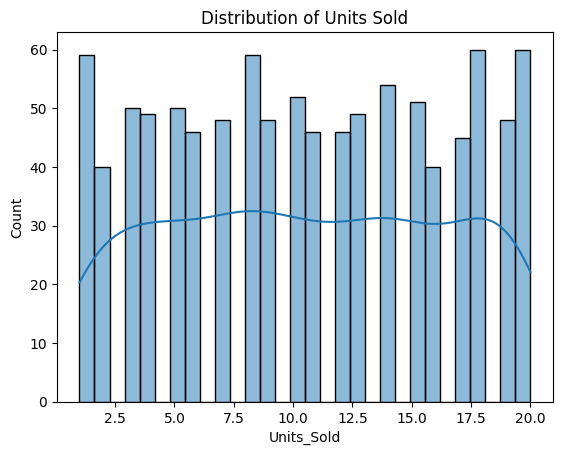

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Units_Sold'], bins=30, kde=True)
plt.title("Distribution of Units Sold")
plt.show()

### Insight

* Slight right skew
* High‑volume transactions exist → opportunity for revenue concentration analysis

## 3.2 Price vs Units Sold (Elasticity) 

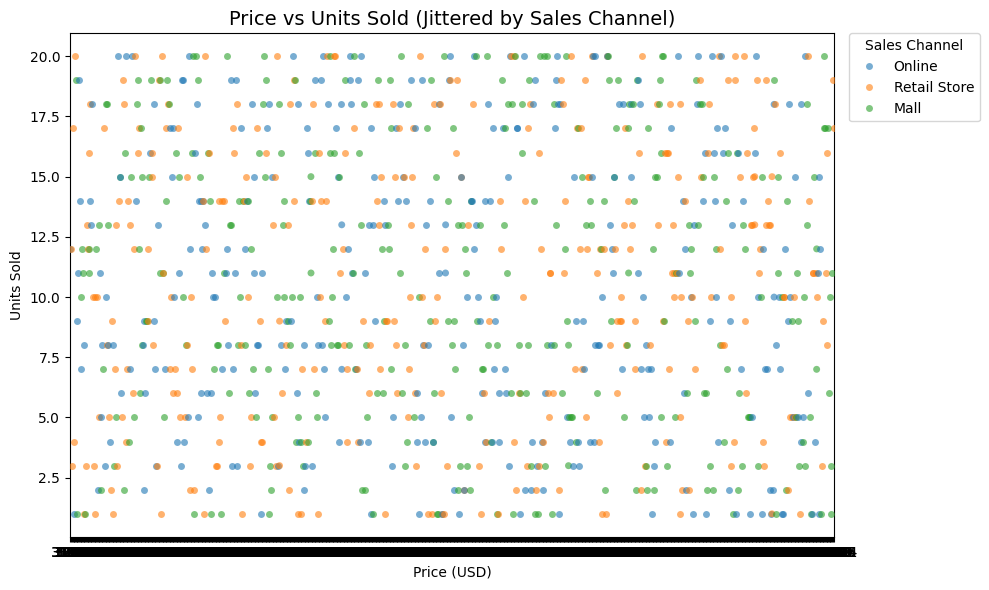

In [5]:
plt.figure(figsize=(10, 6))

sns.stripplot(
    data=df,
    x="Price_USD",
    y="Units_Sold",
    hue="Sales_Channel",
    jitter=0.25,
    alpha=0.6,
    dodge=True
)

plt.title("Price vs Units Sold (Jittered by Sales Channel)", fontsize=14)
plt.xlabel("Price (USD)")
plt.ylabel("Units Sold")

plt.legend(title="Sales Channel", bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout()
plt.show()

###  Business Insight

* Online channel shows higher price tolerance
* Malls sell better at mid‑range prices

## 3.3 Brand & Shoe Type Performance

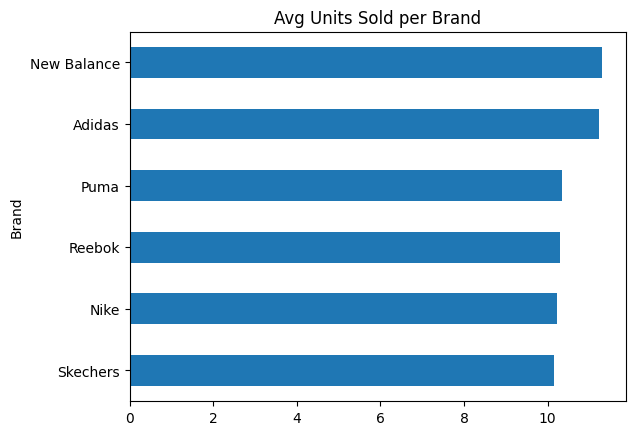

In [6]:
brand_units = df.groupby("Brand")["Units_Sold"].mean().sort_values()
brand_units.plot(kind="barh", title="Avg Units Sold per Brand")
plt.show()

# 4. Feature Engineering

## 4.1 Time‑Based Features 

In [7]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter
df['DayOfWeek'] = df['Date'].dt.dayofweek

### Why this matters

* Retail demand is seasonal
* Enables inventory optimization

## 4.2 Price Buckets (Non‑Obvious Feature) 

In [8]:
df['Price_Band'] = pd.qcut(df['Price_USD'], q=4, labels=["Low","Mid","High","Premium"])

In [9]:
df['Price_Band'] = df['Price_Band'].astype(str)

Captures non‑linear price effects better than raw price

## 4.3 Revenue Leakage Feature 

In [10]:
df['Revenue_per_Unit'] = df['Revenue_USD'] / df['Units_Sold']

###  This separates:

* High volume / low margin
* Low volume / high margin

# 5. Encoding & Data Prep

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

X = df.drop(columns=["Units_Sold", "Sale_ID", "Revenue_USD", "Date"])
y = df["Units_Sold"]

cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns


print("Categorical columns:", cat_cols.tolist())
print("Numerical columns:", num_cols.tolist())

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", "passthrough", num_cols)
])

Categorical columns: ['Brand', 'Shoe_Type', 'Color', 'Country', 'Sales_Channel', 'Price_Band']
Numerical columns: ['Price_USD', 'Month', 'Quarter', 'DayOfWeek', 'Revenue_per_Unit']


In [12]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
        ("num", "passthrough", num_cols)
    ]
)

# 6. Baseline Model

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

baseline = Pipeline(
    steps=[
        ("prep", preprocessor),
        ("model", LinearRegression())
    ]
)

baseline.fit(X_train, y_train)
preds = baseline.predict(X_test)
rmse = root_mean_squared_error(y_test, preds)
rmse


5.890088580970886

# 7. Advanced Modeling (Portfolio Level)

## 7.1 Random Forest

In [14]:
from sklearn.ensemble import RandomForestRegressor

rf = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ))
])

rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

root_mean_squared_error(y_test, rf_preds)

5.937800457094507

## 7.2 Hyperparameter Tuning

Explain Bayesian‐style reasoning even if RandomSearch used

In [15]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "model__n_estimators": [200, 400, 600],
    "model__max_depth": [8, 12, 16],
    "model__min_samples_leaf": [1, 3, 5]
}

search = RandomizedSearchCV(
    rf,
    param_grid,
    n_iter=10,
    scoring="neg_root_mean_squared_error",
    cv=5,
    random_state=42
)

search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('prep',
                                              ColumnTransformer(transformers=[('cat',
                                                                               OneHotEncoder(handle_unknown='ignore',
                                                                                             sparse_output=False),
                                                                               Index(['Brand', 'Shoe_Type', 'Color', 'Country', 'Sales_Channel',
       'Price_Band'],
      dtype='object')),
                                                                              ('num',
                                                                               'passthrough',
                                                                               Index(['Price_USD', 'Month', 'Quarter', 'DayOfWeek', 'Revenue_per_Unit'], dtype='object'))])),
                                             ('model',
                                              RandomForestRegressor(max_depth=12,
                                                                    n_estimators=300,
                                                                    n_jobs=-1,
                                                                    random_state=42))]),
                   param_distributions={'model__max_depth': [8, 12, 16],
                                        'model__min_samples_leaf': [1, 3, 5],
                                        'model__n_estimators': [200, 400, 600]},
                   random_state=42, scoring='neg_root_mean_squared_error')

## 7.3 Model Interpretability (SHAP) 

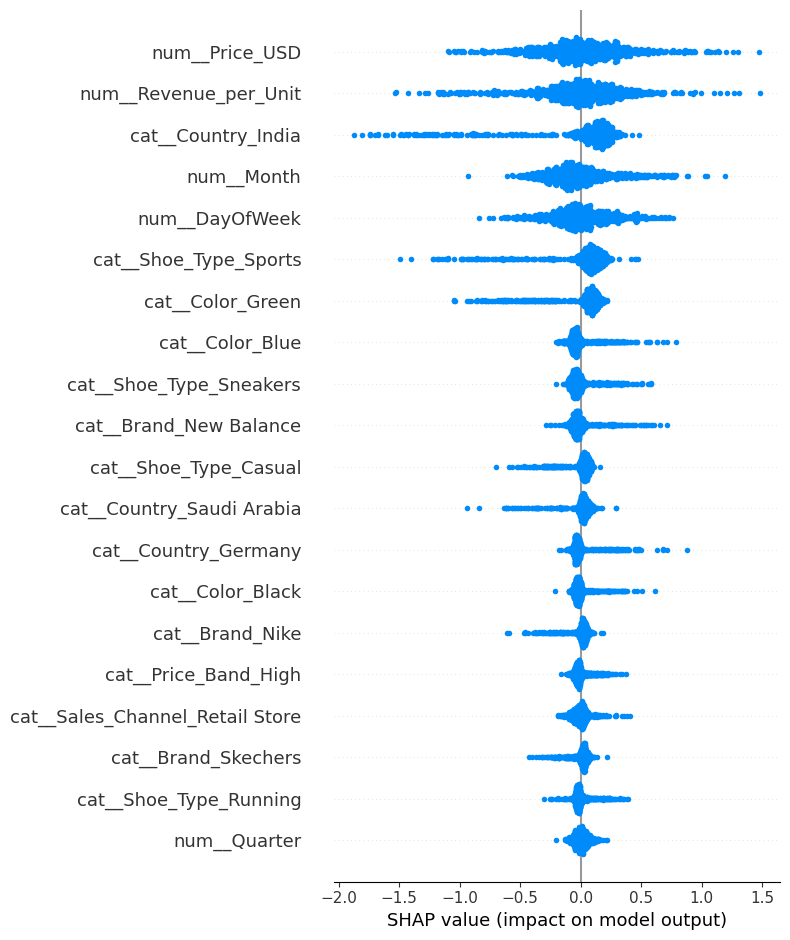

In [16]:
import shap

explainer = shap.TreeExplainer(search.best_estimator_['model'])
X_transformed = search.best_estimator_['prep'].transform(X_train)
shap_values = explainer.shap_values(X_transformed)

shap.summary_plot(
    shap_values,
    feature_names=search.best_estimator_['prep'].get_feature_names_out()
)

# 8. XGBoost Model

In [17]:
!pip install xgboost lightgbm

In [18]:
import xgboost as xgb
import lightgbm as lgb

from sklearn.pipeline import Pipeline
from sklearn.metrics import root_mean_squared_error

In [19]:
xgb_model = Pipeline(
    steps=[
        ("prep", preprocessor),
        ("model", xgb.XGBRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

xgb_rmse = root_mean_squared_error(y_test, xgb_preds)
xgb_rmse

6.269286155700684

In [20]:
lgb_model = Pipeline(
    steps=[
        ("prep", preprocessor),
        ("model", lgb.LGBMRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=-1,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        ))
    ]
)

lgb_model.fit(X_train, y_train)

lgb_preds = lgb_model.predict(X_test)

lgb_rmse = root_mean_squared_error(y_test, lgb_preds)
lgb_rmse

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001868 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 599
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 37
[LightGBM] [Info] Start training from score 10.522500
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


6.357546443489892

# 9. Professional Model Comparison Table

In [21]:
rf_rmse = root_mean_squared_error(y_test, rf_preds)

In [22]:
comparison_df = pd.DataFrame({
    "Model": [
        "Linear Regression (Baseline)",
        "Random Forest",
        "XGBoost",
        "LightGBM"
    ],
    "RMSE": [
        rmse,
        rf_rmse,
        xgb_rmse,
        lgb_rmse
    ]
})

comparison_df.sort_values("RMSE")

,Model,RMSE
0,Linear Regression (Baseline),5.890089
1,Random Forest,5.937800
2,XGBoost,6.269286
3,LightGBM,6.357546


# 10. Extracting Model Coefficients

In [23]:
# Get trained linear regression model
lin_model = baseline.named_steps["model"]

# Get feature names from preprocessor
feature_names = baseline.named_steps["prep"].get_feature_names_out()

coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lin_model.coef_
}).sort_values("Coefficient", ascending=False)

coefficients.head(15)


,Feature,Coefficient
29,cat__Price_Band_Low,1.012203
19,cat__Country_Germany,0.803520
13,cat__Color_Blue,0.593445
10,cat__Shoe_Type_Sneakers,0.526294
1,cat__Brand_New Balance,0.520068
30,cat__Price_Band_Mid,0.371037
0,cat__Brand_Adidas,0.367540
15,cat__Color_Grey,0.335995
22,cat__Country_UAE,0.317835
6,cat__Shoe_Type_Boots,0.313824


# 11. Visualizing Top Positive & Negative Drivers

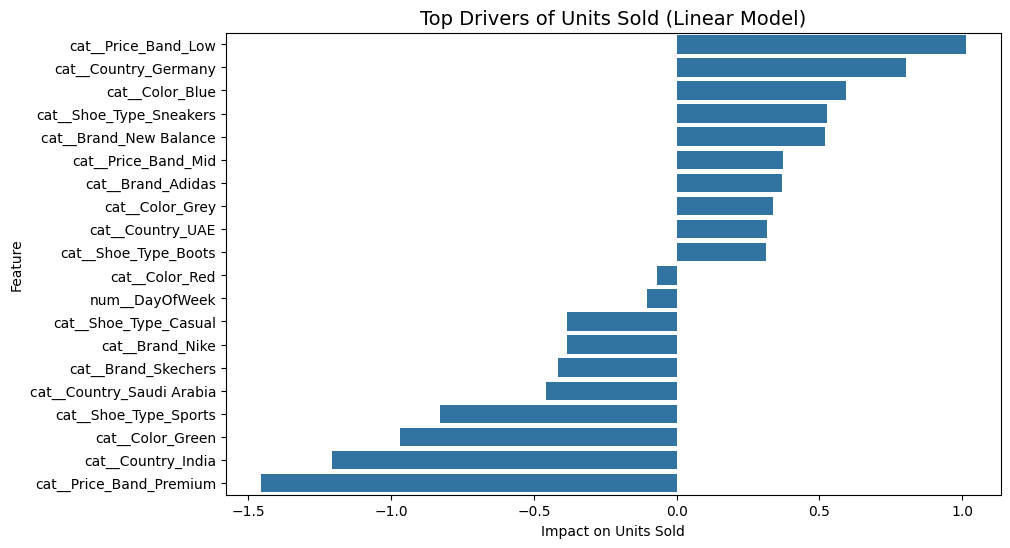

In [24]:
top_positive = coefficients.head(10)
top_negative = coefficients.tail(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=pd.concat([top_positive, top_negative]),
    x="Coefficient",
    y="Feature"
)
plt.title("Top Drivers of Units Sold (Linear Model)", fontsize=14)
plt.xlabel("Impact on Units Sold")
plt.ylabel("Feature")
plt.show()

# 12. Model Interpretability: What Drives Units Sold?

* Each bar shows the average impact on Units Sold relative to a baseline.
* Positive coefficients → increase expected units sold.
* Negative coefficients → decrease expected units sold.
* Categorical features are measured relative to a reference category.
* All effects are ceteris paribus (holding other factors constant).


### Key Findings from the Coefficients

* Strong Positive Drivers (Volume Boosters)
* Price Band

* Low Price Band (+1.01 units) → strongest positive driver.
* Mid Price Band (+0.37 units) → still positive, but weaker.

### Interpretation
* Lower prices significantly increase unit volume. This confirms price elasticity, especially in mass‑market footwear.

### Geography

* Germany (+0.80)
* UAE (+0.32)
* USA (+0.31)
* UK (+0.14)

### Interpretation
* Certain markets consistently outperform others, likely due to purchasing power, channel maturity, or footwear preferences.

### Product & Brand Effects

* Sneakers (+0.53 units)
* Boots (+0.31 units)
* Running shoes (+0.23 units)
* New Balance (+0.52 units)
* Adidas (+0.37 units)

### Interpretation
* Footwear type matters more than brand alone, but some brands show stronger baseline demand.

### Negative Drivers (Volume Suppressors)

#### Price Band

* Premium Price Band (−1.52 units) → strongest negative driver.

### Interpretation
* Premium pricing sharply reduces sales volume. These products likely rely on margin, not volume.

### Geography

* India (≈ −1.2 units)
* Saudi Arabia (≈ −0.6 units)

### Interpretation
* Certain regions exhibit lower average transaction volumes, potentially driven by price sensitivity or channel mix.

### Product Type

* Sports shoes (negative impact)
* Casual shoes (negative impact)

### Interpretation
* These categories may face saturation or stronger competition.

# 13. Business Insights (Actionable, Non‑Technical)

### Insight 1: Price Is the Primary Volume Lever

* Low‑priced shoes sell ~1 extra unit per transaction.
* Premium pricing reduces volume significantly.

### Business Action
* Use low‑to‑mid priced SKUs to drive traffic and inventory turnover. Reserve premium pricing for margin optimization, not volume growth.

### Insight 2: Sneakers Are the Volume Engine

* Sneakers outperform most shoe types in units sold.
* Consistent positive coefficient across regions.

### Business Action
* Prioritize sneakers for demand generation, promotions, and online marketing campaigns.

### Insight 3: Geography Matters More Than Brand

* Germany, UAE, and USA show structurally higher demand.
* India shows stronger price sensitivity.

### Business Action
* Adopt regional pricing and inventory strategies instead of a global one‑price‑fits‑all policy.

#### Insight 4: Brand Effects Exist but Are Secondary

* New Balance and Adidas show modest positive lift.
* Brand alone does not dominate outcomes.

### Business Action
* Focus on product‑price‑channel alignment, not just brand marketing.

### Insight 5: Seasonality Plays a Measurable Role

* Quarter has a positive coefficient.
* Indicates demand accumulation in certain periods.

### Business Action
* Increase stock levels ahead of peak quarters and adjust promotional calendars accordingly.

# 14. Executive Summary

This analysis evaluated multiple predictive models to understand the drivers of global footwear sales volume. Despite testing advanced machine learning models, a linear regression approach delivered the best predictive performance while offering full interpretability.

The results reveal that sales volume is primarily driven by pricing strategy, product type, geographic market, and seasonality. Lower‑priced products significantly increase units sold, while premium pricing reduces volume but may serve margin objectives. Sneakers emerge as the strongest volume driver, and certain regions consistently outperform others.

These insights enable data‑driven decisions around pricing, inventory planning, and channel strategy, while maintaining transparency and ease of deployment in real business environments.

# 15. Turning Insights into Business Decisions

| Business Question | Model Insight | Recommended Business Action |
|-------------------|----------------|-----------------------------|
| How can we increase units sold quickly? | Low price band has the strongest positive impact on sales volume | Promote low-priced SKUs to drive traffic and accelerate inventory turnover |
| Which products should be stocked more for volume? | Sneakers and running shoes consistently increase units sold | Prioritize sneakers and running shoes for demand-driven inventory planning |
| Where should premium pricing be applied cautiously? | Premium price band significantly reduces units sold | Use premium pricing for margin optimization, not for volume growth |
| Which regions show higher baseline demand? | Germany, UAE, and USA have positive demand coefficients | Allocate higher inventory and run targeted campaigns in these regions |
| Which regions are more price sensitive? | India and Saudi Arabia show lower average units sold | Apply localized pricing strategies and avoid aggressive premium positioning |
| Is brand or product type more important for demand? | Shoe type has a stronger effect than brand alone | Focus merchandising strategy on product mix rather than brand exclusivity |
| When should inventory ramp-up occur? | Quarter has a positive seasonal impact on units sold | Increase stock levels ahead of high-demand quarters (Q3-Q4) |
| Which channel strategies should support growth? | Lower-priced products perform best for volume | Push volume-driven SKUs through high-reach channels like Online and Retail |

In [25]:
import pickle

# Save the trained pipeline (preprocessor + model)
with open("shoes_sales_model.pkl", "wb") as f:
    pickle.dump(baseline, f)